In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import plot_model
import pydot
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# Fashion MNIST - classification 

In [6]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()
print(X_train_full.shape)
print(X_train_full.dtype)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
uint8


In [49]:
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [51]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
 "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]


In [54]:
class_names[y_train[0]]

'Coat'

In [159]:
model = tf.keras.Sequential([
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(300, activation='relu'),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

C:\Users\EdwinVivekN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [57]:
model.summary()
#28 * 28 = 784 inputs
# 784 * 300 neurons + 300 bias = 235500 params
# 300 neurons * 100 neurons + 100 bias = 30100 params
# 100 neurons * 10 neurons + 10 bias = 1010 params

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [74]:
hidden1 = model.layers[1]
weights, biases = hidden1.get_weights()  #get the random weights assigned
print(f' Weights - {weights.shape}\n Biases - {biases.shape}')

 Weights - (784, 300)
 Biases - (300,)


In [160]:
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))
#55000 (samples) / 32  (batch size) = 1719 batches

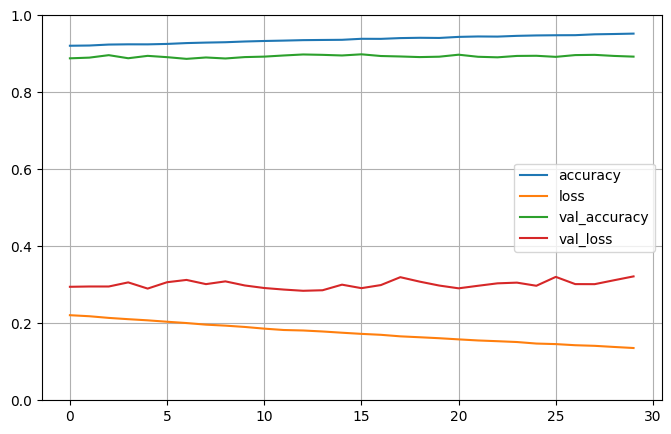

In [96]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()


In [97]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8361 - loss: 90.9057


[91.83612823486328, 0.8346999883651733]

In [98]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [102]:
y_pred = model.predict_classes(X_new)
y_pred

AttributeError: 'Sequential' object has no attribute 'predict_classes'

In [105]:
class_names[y_proba[0]]

TypeError: only integer scalar arrays can be converted to a scalar index

In [126]:
print("Prediction:")
for i, _ in enumerate(y_proba):
    print(class_names[np.argmax(y_proba[i])])

y_new = y_test[:3]
print("\nActual:") 
for i in y_new:
    print(class_names[i])

Prediction:
Ankle boot
Coat
Trouser

Actual:
Ankle boot
Pullover
Trouser


In [133]:
#save and restore
model.save("fashion_mnist.keras")
loaded_model = keras.models.load_model('fashion_mnist.h5')
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,612 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [152]:
#callbacks
checkpoint_cb = keras.callbacks.ModelCheckpoint('fashion_mnist_cb.h5', save_best_only=True)
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid), callbacks=[checkpoint_cb])


Epoch 1/30
1715/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6840 - loss: 0.9865

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6842 - loss: 0.9857 - val_accuracy: 0.8254 - val_loss: 0.5241
Epoch 2/30
1710/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8231 - loss: 0.5095

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8232 - loss: 0.5094 - val_accuracy: 0.8456 - val_loss: 0.4592
Epoch 3/30
1705/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8402 - loss: 0.4557

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8402 - loss: 0.4556 - val_accuracy: 0.8634 - val_loss: 0.4099
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8479 - loss: 0.4289 - val_accuracy: 0.8588 - val_loss: 0.4124
Epoch 5/30
1711/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8571 - loss: 0.4069

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8571 - loss: 0.4069 - val_accuracy: 0.8686 - val_loss: 0.3828
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8632 - loss: 0.3903 - val_accuracy: 0.8602 - val_loss: 0.3854
Epoch 7/30
1712/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8688 - loss: 0.3692

...

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8903 - loss: 0.3076 - val_accuracy: 0.8832 - val_loss: 0.3324
Epoch 14/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8897 - loss: 0.3097 - val_accuracy: 0.8788 - val_loss: 0.3470
Epoch 15/30
1713/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8917 - loss: 0.2985

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8917 - loss: 0.2985 - val_accuracy: 0.8840 - val_loss: 0.3224
Epoch 16/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8962 - loss: 0.2874 - val_accuracy: 0.8800 - val_loss: 0.3293
Epoch 17/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8955 - loss: 0.2903 - val_accuracy: 0.8814 - val_loss: 0.3337
Epoch 18/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8990 - loss: 0.2802 - val_accuracy: 0.8790 - val_loss: 0.3327
Epoch 19/30
1697/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8992 - loss: 0.2786

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8992 - loss: 0.2786 - val_accuracy: 0.8896 - val_loss: 0.3079
Epoch 20/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9040 - loss: 0.2684 - val_accuracy: 0.8812 - val_loss: 0.3313
Epoch 21/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9027 - loss: 0.2717 - val_accuracy: 0.8892 - val_loss: 0.3115
Epoch 22/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9072 - loss: 0.2611 - val_accuracy: 0.8896 - val_loss: 0.3100
Epoch 23/30
1691/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9073 - loss: 0.2595

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9073 - loss: 0.2594 - val_accuracy: 0.8906 - val_loss: 0.3013
Epoch 24/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9099 - loss: 0.2504 - val_accuracy: 0.8880 - val_loss: 0.3119
Epoch 25/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9094 - loss: 0.2502 - val_accuracy: 0.8932 - val_loss: 0.3020
Epoch 26/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9103 - loss: 0.2462

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9103 - loss: 0.2462 - val_accuracy: 0.8962 - val_loss: 0.2945
Epoch 27/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9161 - loss: 0.2357 - val_accuracy: 0.8908 - val_loss: 0.3140
Epoch 28/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9157 - loss: 0.2357 - val_accuracy: 0.8940 - val_loss: 0.2966
Epoch 29/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9168 - loss: 0.2291 - val_accuracy: 0.8900 - val_loss: 0.3045
Epoch 30/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9200 - loss: 0.2255 - val_accuracy: 0.8914 - val_loss: 0.2956


In [206]:
#Tensorboard
root_logdir = os.path.join(os.curdir, "my_logs")

def get_run_logdir():
     import time
     run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
     return os.path.join(root_logdir, run_id)

run_logdir = get_run_logdir()
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid), callbacks=[tensorboard_cb])
 

NameError: name 'model' is not defined

# XOR Neural networks

In [70]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

xor_model = keras.models.Sequential([
    keras.layers.InputLayer(shape=[2]),
    keras.layers.Dense(4, activation='tanh'),
    keras.layers.Dense(1, activation='sigmoid')
])

In [71]:
xor_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 4)                   │              12 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

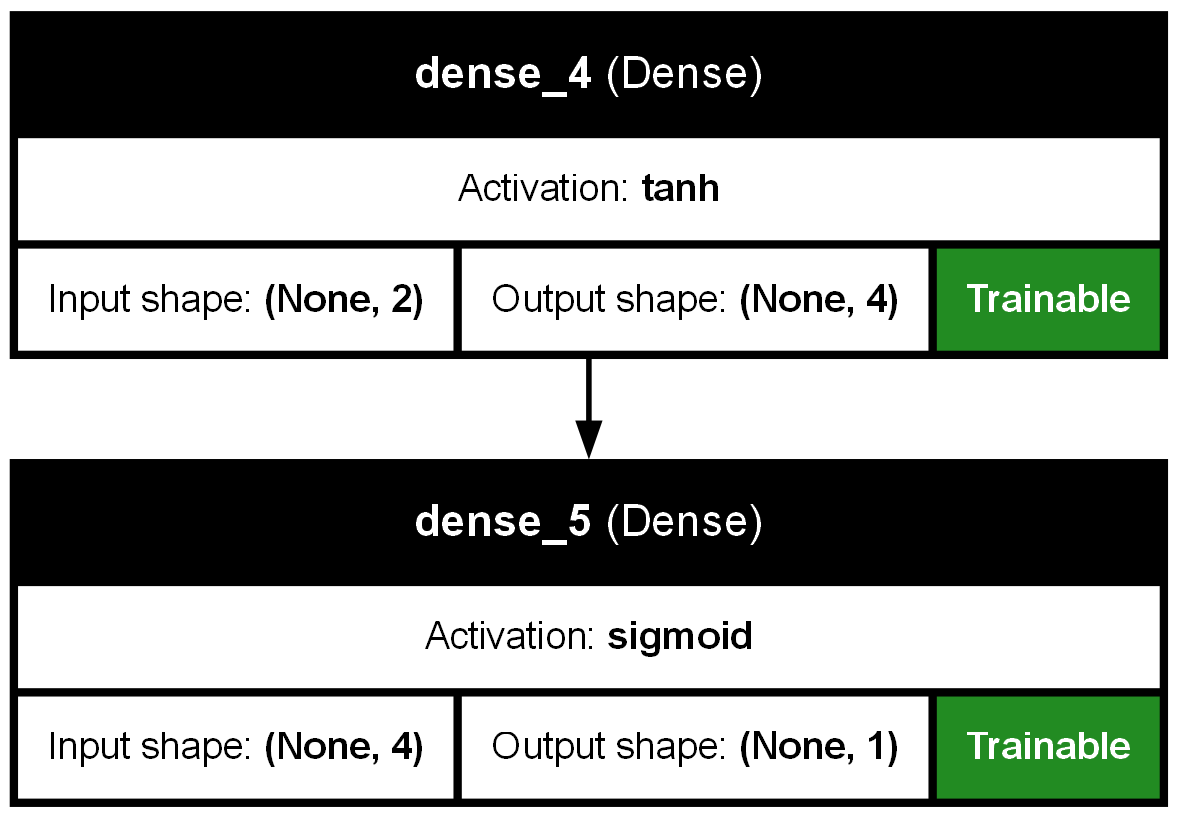

In [72]:
plot_model(xor_model, to_file="./xor_model.png", show_shapes=True, show_layer_names=True, show_layer_activations=True, show_trainable=True)

In [ ]:
xor_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
early_stopping = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True) 
history = xor_model.fit(X, y, epochs=1000, callbacks=[early_stopping])   #set validation_split=<> for early stopping to trigger

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7500 - loss: 0.7297
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.5000 - loss: 0.7291
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5000 - loss: 0.7285
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5000 - loss: 0.7279
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5000 - loss: 0.7273
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.5000 - loss: 0.7267
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5000 - loss: 0.7261
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.5000 - loss: 0.7255
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5000 - loss: 0.7250
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.5000 - loss: 0.7244
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5000 - loss: 0.7238
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accurac

In [75]:
# Evaluate
loss, acc = xor_model.evaluate(X, y)
print("Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 1.0000 - loss: 0.2773
Accuracy: 1.0


<Axes: >

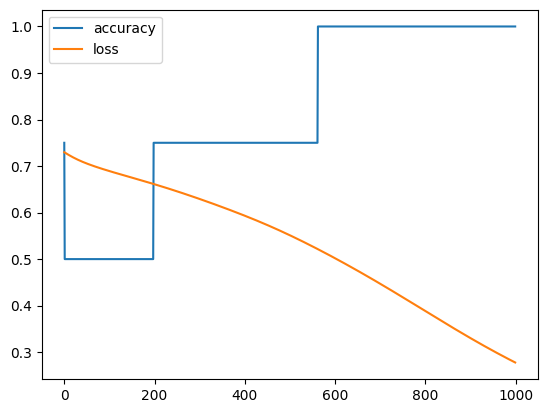

In [203]:
pd.DataFrame(history.history).plot()

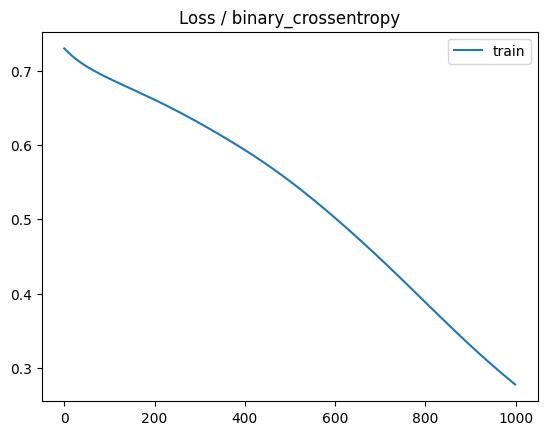

In [77]:
# plot loss during training
plt.title('Loss / binary_crossentropy')
plt.plot(history.history['loss'], label='train')
#plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [76]:
predictions = xor_model.predict(X)
print("\nPredictions:")
print(np.round(predictions)) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step

Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]


model.get_weights() will return a list of 4 NumPy arrays: 

[0]: Hidden layer weights (shape: )

[1]: Hidden layer biases (shape: )

[2]: Output layer weights (shape: )

[3]: Output layer biases (shape: ) 

In [12]:
w = xor_model.get_weights()
w

[array([[-1.6665765 , -0.8525774 , -1.6796974 , -1.7386101 ],
        [ 2.0177484 , -0.96965796,  1.932963  ,  1.6223516 ]],
       dtype=float32),
 array([ 0.8485449 , -0.45717525,  0.94763523, -0.77352005], dtype=float32),
 array([[-1.4170024],
        [-1.3785567],
        [-1.3984627],
        [ 2.1833477]], dtype=float32),
 array([0.9575027], dtype=float32)]

In [21]:
xor_model.weights

[<Variable path=sequential/dense/kernel, shape=(2, 4), dtype=float32, value=[[-1.6665765  -0.8525774  -1.6796974  -1.7386101 ]
  [ 2.0177484  -0.96965796  1.932963    1.6223516 ]]>,
 <Variable path=sequential/dense/bias, shape=(4,), dtype=float32, value=[ 0.8485449  -0.45717525  0.94763523 -0.77352005]>,
 <Variable path=sequential/dense_1/kernel, shape=(4, 1), dtype=float32, value=[[-1.4170024]
  [-1.3785567]
  [-1.3984627]
  [ 2.1833477]]>,
 <Variable path=sequential/dense_1/bias, shape=(1,), dtype=float32, value=[0.9575027]>]

In [42]:
# Generate a grid for visualization
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))  # Explanation of this 2 lines of code with chatgpt:
grid = np.concatenate((xx.ravel().reshape(-1, 1), yy.ravel().reshape(-1, 1)), axis=1)  # https://chatgpt.com/share/67a9f604-6b98-8003-9f48-83fe24781b4a

# The final grid array has shape (10000, 2), where each row is a coordinate [x, y].
print(f"grid shape is {grid.shape}")
grid

grid shape is (10000, 2)


array([[-1.        , -1.        ],
       [-0.96969697, -1.        ],
       [-0.93939394, -1.        ],
       ...,
       [ 1.93939394,  2.        ],
       [ 1.96969697,  2.        ],
       [ 2.        ,  2.        ]], shape=(10000, 2))

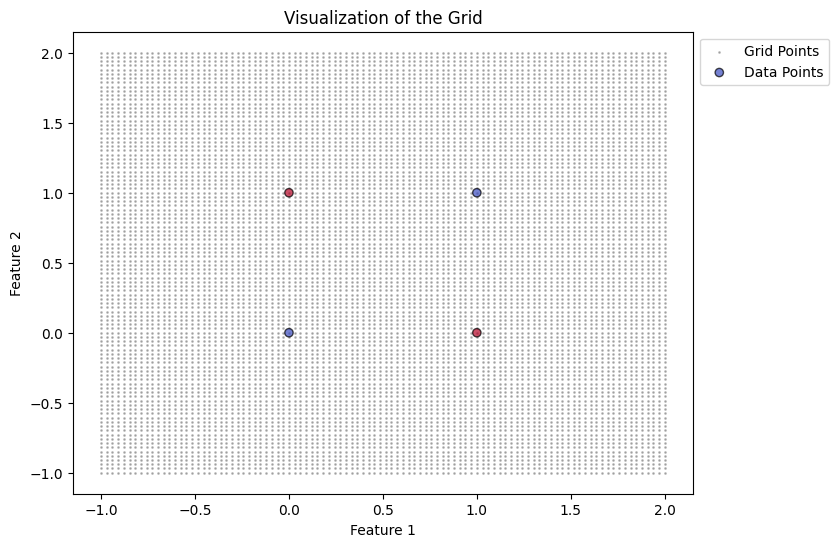

In [48]:
# Define a colormap with exactly 4 distinct colors
colors = ['blue', 'green', 'red', 'purple']  # You can customize these
cmap = ListedColormap(colors)

# Visualization of the Grid
plt.figure(figsize=(8, 6))
plt.scatter(grid[:, 0], grid[:, 1], s=1, color="gray", alpha=0.5, label="Grid Points")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.7, label="Data Points")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Visualization of the Grid")

# Create a legend with class labels
legend_patches = [mpatches.Patch(color=colors[i], label=f'Class {i}') for i in range(4)]
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

In [54]:
xor_model.layers[0].get_weights()[0]

array([[-1.6665765 , -0.8525774 , -1.6796974 , -1.7386101 ],
       [ 2.0177484 , -0.96965796,  1.932963  ,  1.6223516 ]],
      dtype=float32)

# Regression Neural Networks

In [8]:
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD

In [9]:
X, y = make_regression(n_samples=1000, n_features=20, noise=0.1, random_state=1)

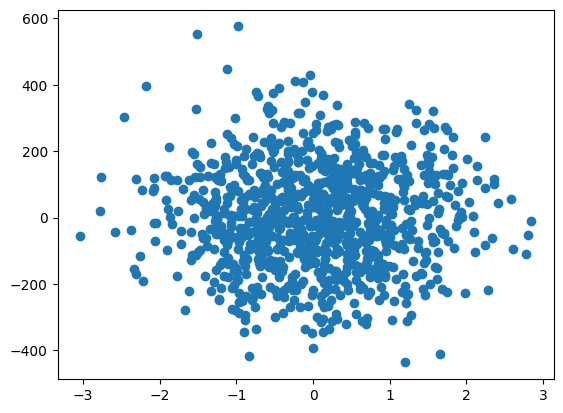

In [92]:
plt.scatter(X[:,3],y)

In [10]:
# standardize dataset
X = StandardScaler().fit_transform(X)
y = StandardScaler().fit_transform(y.reshape(len(y),1))[:,0]
# split into train and test
n_train = 500
trainX, testX = X[:n_train, :], X[n_train:, :]
trainy, testy = y[:n_train], y[n_train:]

In [14]:
trainX.shape

(500, 20)

In [123]:
reg_model = keras.models.Sequential([
    keras.layers.InputLayer(shape=[20]),
    keras.layers.Dense(25, activation='relu', kernel_initializer='he_uniform'),
    keras.layers.Dense(1, activation='linear')
])

reg_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                     │ (None, 25)                  │             525 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 551 (2.15 KB)

 Trainable params: 551 (2.15 KB)

 Non-trainable params: 0 (0.00 B)

In [124]:
opt = SGD(learning_rate=0.01, momentum=0.9)
reg_model.compile(loss='mean_squared_error', optimizer=opt, metrics=['mse'])

In [125]:
# fit model
reg_history = reg_model.fit(trainX, trainy, validation_data=(testX, testy), epochs=100, verbose=1)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.7477 - mse: 1.7477 - val_loss: 0.6897 - val_mse: 0.6897
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5427 - mse: 0.5427 - val_loss: 0.3586 - val_mse: 0.3586
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2391 - mse: 0.2391 - val_loss: 0.1995 - val_mse: 0.1995
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1418 - mse: 0.1418 - val_loss: 0.1434 - val_mse: 0.1434
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1158 - mse: 0.1158 - val_loss: 0.1168 - val_mse: 0.1168
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0903 - mse: 0.0903 - val_loss: 0.0981 - val_mse: 0.0981
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0717 - mse: 0.0717 - val_loss: 0.0922 - val_mse: 0.0922
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0576 - mse: 0.0576 - val_loss: 0.0840 - val_mse: 0.0840
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0

In [126]:
# evaluate the model
train_mse = reg_model.evaluate(trainX, trainy, verbose=1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - mse: 0.0011 


In [127]:
test_mse = reg_model.evaluate(testX, testy, verbose=1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0029 - mse: 0.0029 


In [128]:
print('Train: %.3f, Test: %.3f' % (train_mse[0], test_mse[0]))

Train: 0.001, Test: 0.003


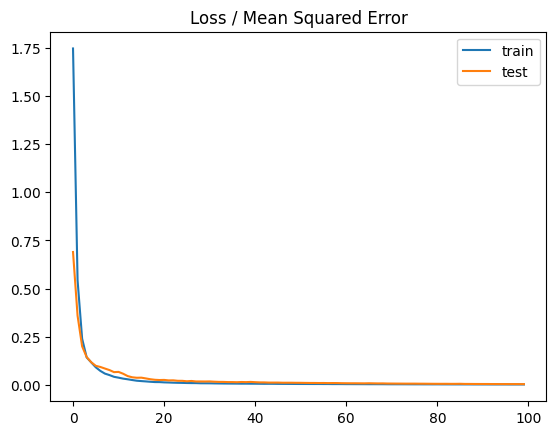

In [129]:
# plot loss during training
plt.title('Loss / Mean Squared Error')
plt.plot(reg_history.history['loss'], label='train')
plt.plot(reg_history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [141]:
predictions = reg_model.predict(testX)
pd.DataFrame

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [153]:
pd.DataFrame(np.c_[testy, predictions], columns=["Actual", "Predicted"])

,Actual,Predicted
0,0.296332,0.300182
1,0.715953,0.710490
2,-0.961041,-0.913824
3,1.454430,1.458641
4,0.552522,0.491567
...,...,...
495,1.106195,1.090497
496,1.186528,1.205095
497,0.351925,0.297408
498,0.190105,0.215512


# Number Sequence generation 

In [3]:
X = np.array([i for i in range(1, 100)])
y = np.array([i + 1 for i in range(1, 100)])
print(X.shape, y.shape)

(99,) (99,)


In [4]:
# Reshape input for Keras (samples, features)
X = X.reshape(-1, 1)
y = y.reshape(-1, 1)
print(X.shape, y.shape)

(99, 1) (99, 1)


In [5]:
num_seq_model = keras.models.Sequential([
    keras.layers.InputLayer([1]),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(1)  #activation = linear, default
])

num_seq_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 50)                  │             100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
num_seq_model.compile(optimizer='adam', loss='mse')

In [176]:
num_seq_model.fit(X, y, epochs=250, verbose=1) 

Epoch 1/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 4287.4668
Epoch 2/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4014.8779
Epoch 3/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3751.4678
Epoch 4/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3507.6462
Epoch 5/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3264.0740 
Epoch 6/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3036.1929 
Epoch 7/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2817.0076
Epoch 8/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2611.2278
Epoch 9/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2418.3315
Epoch 10/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2238.3464 
Epoch 11/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2059.4509
Epoch 12/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1906.7748
Epoch 13/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1760.3389
Epoch 14/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1620.8481
Epoch 15/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s

In [200]:
# Predict the next number in the sequence
test_input = np.array([50,60,100, 200,500]).reshape(-1,1)
predicted = num_seq_model.predict(test_input)

for i, _ in enumerate(test_input):
    print(f"Input: {test_input[i][0]} → Predicted Output: {predicted[i][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Input: 50 → Predicted Output: 50.95
Input: 60 → Predicted Output: 60.98
Input: 100 → Predicted Output: 101.11
Input: 200 → Predicted Output: 201.43
Input: 500 → Predicted Output: 502.38


In [15]:
#Tensorboard
root_logdir = os.path.join(os.curdir, "my_logs")

def get_run_logdir():
     import time
     run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
     return os.path.join(root_logdir, run_id)

run_logdir = get_run_logdir()
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)
history = num_seq_model.fit(X, y, epochs=250, callbacks=[tensorboard_cb])

Epoch 1/250


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'None' of layer 'dense' is incompatible with the layer: expected axis -1 of input shape to have value 1, but received input with shape (None, 20)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 20), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>